In [10]:
#VW & Audi Used Car Price Prediction
# Volkswagen, Audi, VW, Golf, A4 are trademarks of Volkswagen AG.
# Independent educational case study. Not affiliated with VW AG.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
sns.set_palette('muted')

print('Libraries loaded successfully.')


import IPython.display
def proov_tick(task_id):
    IPython.display.display(IPython.display.Javascript(f'window.parent.postMessage({{ type: "PROOV_CHECKPOINT", checkpoint: "{task_id}" }}, "*");'))
proov_tick('setup_complete')


Libraries loaded successfully.


<IPython.core.display.Javascript object>

In [11]:
import pandas as pd

print("Loading datasets from local files...")

vw = pd.read_csv("vw.csv")
audi = pd.read_csv("audi.csv")

print(f"✓ Loaded vw.csv: {len(vw):,} rows")
print(f"✓ Loaded audi.csv: {len(audi):,} rows")
print(f"\nTotal: {len(vw) + len(audi):,} listings ready for analysis.")

Loading datasets from local files...
✓ Loaded vw.csv: 15,157 rows
✓ Loaded audi.csv: 10,668 rows

Total: 25,825 listings ready for analysis.


In [12]:
# Quick sanity check
print('=== VW Dataset ===')
print(f'Shape: {vw.shape}')
display(vw.head(3))

print('\n=== Audi Dataset ===')
print(f'Shape: {audi.shape}')
display(audi.head(3))

=== VW Dataset ===
Shape: (15157, 9)


,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,T-Roc,2019,25000,Automatic,13904,Diesel,145,49.6,2.0
1,T-Roc,2019,26883,Automatic,4562,Diesel,145,49.6,2.0
2,T-Roc,2019,20000,Manual,7414,Diesel,145,50.4,2.0



=== Audi Dataset ===
Shape: (10668, 9)


,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,A1,2017,12500,Manual,15735,Petrol,150,55.4,1.4
1,A6,2016,16500,Automatic,36203,Diesel,20,64.2,2.0
2,A1,2016,11000,Manual,29946,Petrol,30,55.4,1.4


In [13]:
import pandas as pd

vw = pd.read_csv("vw.csv")
audi = pd.read_csv("audi.csv")

vw["brand"] = "Volkswagen"
audi["brand"] = "Audi"

df = pd.concat([vw, audi], ignore_index=True)

print(df.shape)
print(df.columns)
print(df["brand"].value_counts())

(25825, 10)
Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize', 'brand'],
      dtype='object')
brand
Volkswagen    15157
Audi          10668
Name: count, dtype: int64


In [14]:
# Validation
assert 'df' in dir(), "Name your combined DataFrame 'df'"
assert 'brand' in df.columns, "Missing 'brand' column"
assert df.shape[0] > 25000, f"Expected 25,000+ rows, got {df.shape[0]}"
print(f'OK Combined dataset: {df.shape[0]:,} rows, {df.shape[1]} columns')
print(f'   Brands: {df["brand"].value_counts().to_dict()}')
proov_tick('task_1_1')


OK Combined dataset: 25,825 rows, 10 columns
   Brands: {'Volkswagen': 15157, 'Audi': 10668}


<IPython.core.display.Javascript object>

In [15]:
proov_tick('task_1_2')

<IPython.core.display.Javascript object>

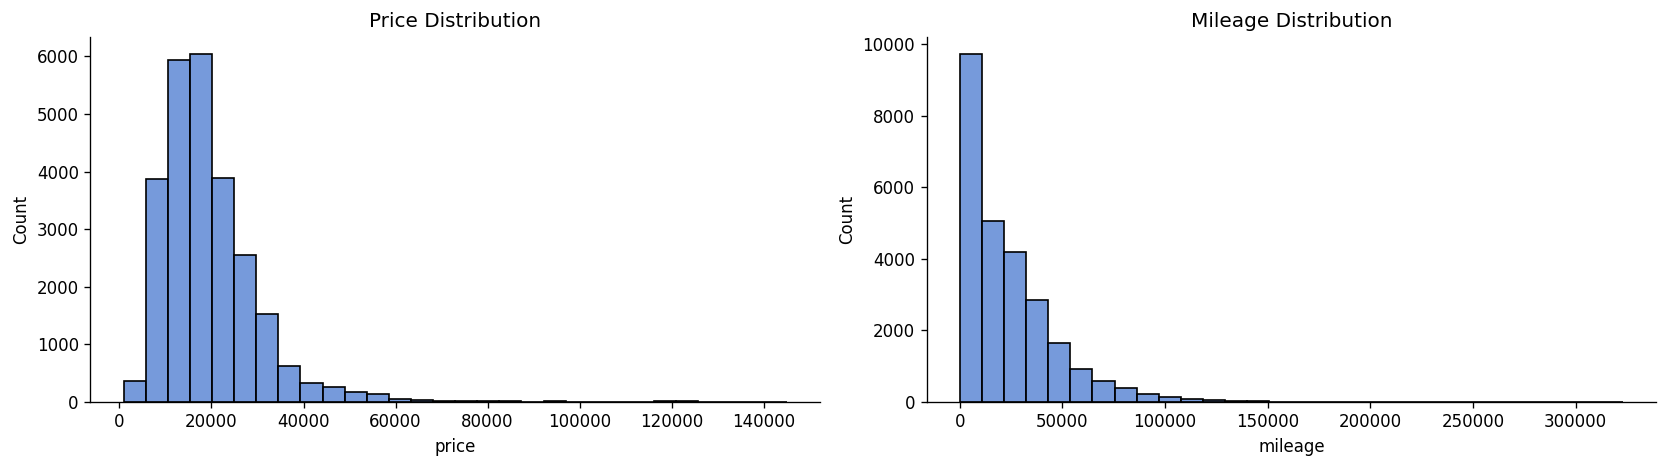

<IPython.core.display.Javascript object>

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df['price'], bins=30, ax=axes[0])
axes[0].set_title('Price Distribution')

sns.histplot(df['mileage'], bins=30, ax=axes[1])
axes[1].set_title('Mileage Distribution')

plt.tight_layout()
plt.show()

proov_tick('task_1_3')

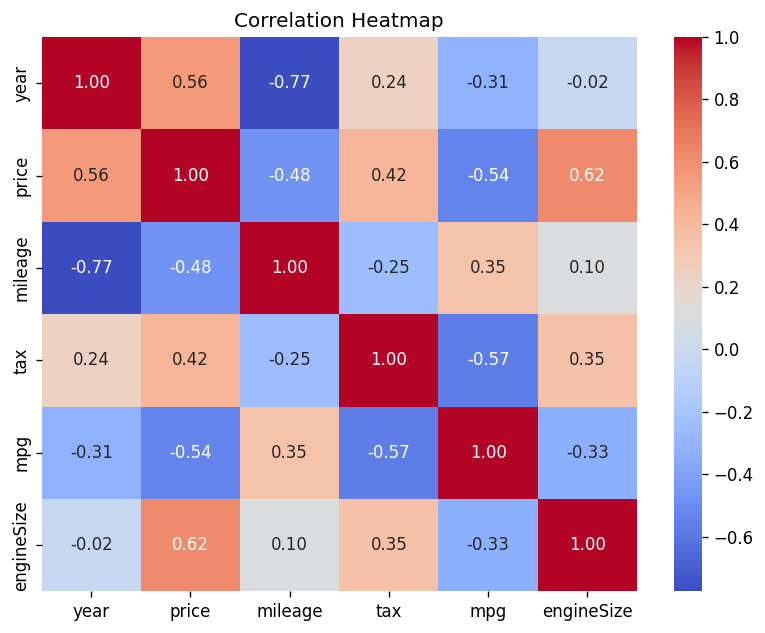

<IPython.core.display.Javascript object>

In [18]:
fig, ax = plt.subplots(figsize=(8, 6))

# Select numeric columns and compute correlations
corr = df.select_dtypes(include='number').corr()

# Heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', ax=ax)

ax.set_title('Correlation Heatmap')

plt.show()

proov_tick('task_1_4')

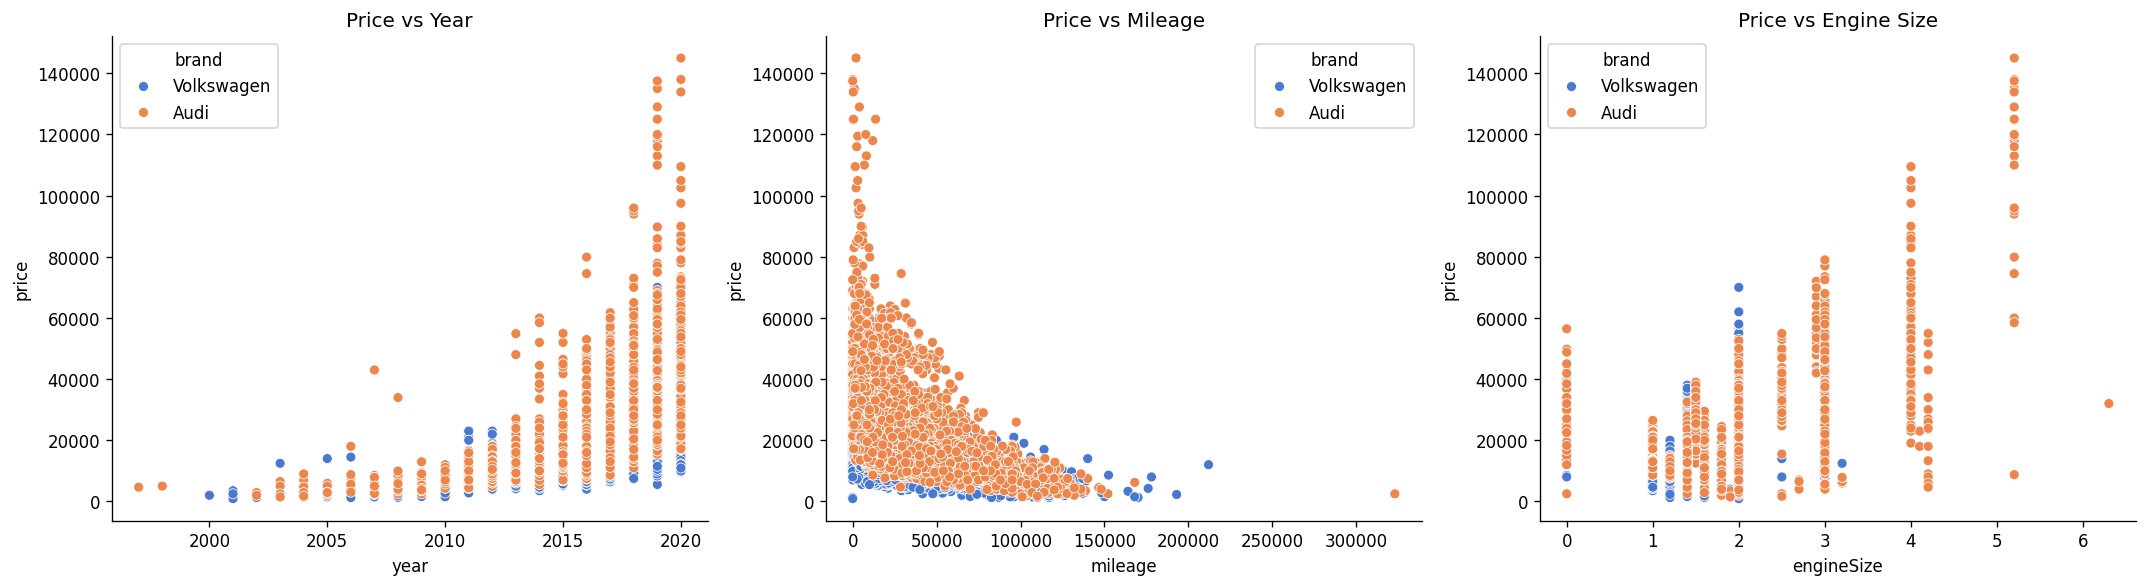

<IPython.core.display.Javascript object>

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Price vs Year
sns.scatterplot(
    data=df,
    x='year',
    y='price',
    hue='brand',
    ax=axes[0]
)
axes[0].set_title('Price vs Year')

# Price vs Mileage
sns.scatterplot(
    data=df,
    x='mileage',
    y='price',
    hue='brand',
    ax=axes[1]
)
axes[1].set_title('Price vs Mileage')

# Price vs Engine Size
sns.scatterplot(
    data=df,
    x='engineSize',
    y='price',
    hue='brand',
    ax=axes[2]
)
axes[2].set_title('Price vs Engine Size')

plt.tight_layout()
plt.show()

proov_tick('task_1_5')

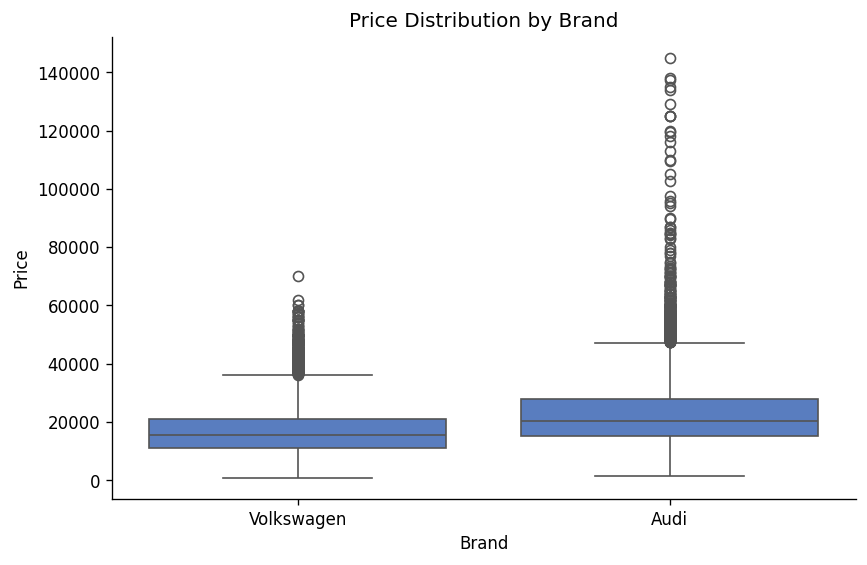

<IPython.core.display.Javascript object>

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='brand',
    y='price',
    ax=ax
)

ax.set_title('Price Distribution by Brand')
ax.set_xlabel('Brand')
ax.set_ylabel('Price')

plt.show()

proov_tick('task_1_6')

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# 1. Define X and y
X = df[['mileage']]
y = df['price']

# 2. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# 3. Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Predictions
y_pred = model.predict(X_test)

# 5. MAE
mae = mean_absolute_error(y_test, y_pred)

print(f"Mean Absolute Error (MAE): £{mae:,.2f}")

proov_tick('task_1_7')

Mean Absolute Error (MAE): £6,092.82


<IPython.core.display.Javascript object>